In [1]:
!pip install -q missingno plotly

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import missingno as msno
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('Libraries loaded ✅')

Libraries loaded ✅


In [3]:

BASE = "/content/"

train_values = pd.read_csv(f'{BASE}Training_Set_Values.csv', index_col='id')
train_labels = pd.read_csv(f'{BASE}Training_Set_Labels.csv', index_col='id')
test_values  = pd.read_csv(f'{BASE}Test_Set_Values.csv',     index_col='id')

# Merge features + labels
train = train_values.join(train_labels)

print(f'Train shape : {train.shape}')
print(f'Test  shape : {test_values.shape}')
train.head()

Train shape : (59400, 40)
Test  shape : (14850, 39)


,amount_tsh,date_recorded,funder,gps_height,installer,longitude,latitude,wpt_name,num_private,basin,...,water_quality,quality_group,quantity,quantity_group,source,source_type,source_class,waterpoint_type,waterpoint_type_group,status_group
id,,,,,,,,,,,,,,,,,,,,,
69572,6000.0,2011-03-14,Roman,1390,Roman,34.938093,-9.856322,none,0,Lake Nyasa,...,soft,good,enough,enough,spring,spring,groundwater,communal standpipe,communal standpipe,functional
8776,0.0,2013-03-06,Grumeti,1399,GRUMETI,34.698766,-2.147466,Zahanati,0,Lake Victoria,...,soft,good,insufficient,insufficient,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional
34310,25.0,2013-02-25,Lottery Club,686,World vision,37.460664,-3.821329,Kwa Mahundi,0,Pangani,...,soft,good,enough,enough,dam,dam,surface,communal standpipe multiple,communal standpipe,functional
67743,0.0,2013-01-28,Unicef,263,UNICEF,38.486161,-11.155298,Zahanati Ya Nanyumbu,0,Ruvuma / Southern Coast,...,soft,good,dry,dry,machine dbh,borehole,groundwater,communal standpipe multiple,communal standpipe,non functional
19728,0.0,2011-07-13,Action In A,0,Artisan,31.130847,-1.825359,Shuleni,0,Lake Victoria,...,soft,good,seasonal,seasonal,rainwater harvesting,rainwater harvesting,surface,communal standpipe,communal standpipe,functional


Dataset Overview

In [4]:
print('=== SHAPE ===')
print(f'Rows: {train.shape[0]:,}  |  Columns: {train.shape[1]}')

print('\n=== DTYPES ===')
print(train.dtypes.value_counts())

print('\n=== NUMERICAL SUMMARY ===')
train.describe(include=[np.number]).T

=== SHAPE ===
Rows: 59,400  |  Columns: 40

=== DTYPES ===
object     31
int64       6
float64     3
Name: count, dtype: int64

=== NUMERICAL SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
amount_tsh,59400.0,317.650385,2997.574558,0.00000,0.000000,0.000000,20.000000,3.500000e+05
gps_height,59400.0,668.297239,693.116350,-90.00000,0.000000,369.000000,1319.250000,2.770000e+03
longitude,59400.0,34.077427,6.567432,0.00000,33.090347,34.908743,37.178387,4.034519e+01
latitude,59400.0,-5.706033,2.946019,-11.64944,-8.540621,-5.021597,-3.326156,-2.000000e-08
num_private,59400.0,0.474141,12.236230,0.00000,0.000000,0.000000,0.000000,1.776000e+03
region_code,59400.0,15.297003,17.587406,1.00000,5.000000,12.000000,17.000000,9.900000e+01
district_code,59400.0,5.629747,9.633649,0.00000,2.000000,3.000000,5.000000,8.000000e+01
population,59400.0,179.909983,471.482176,0.00000,0.000000,25.000000,215.000000,3.050000e+04
construction_year,59400.0,1300.652475,951.620547,0.00000,0.000000,1986.000000,2004.000000,2.013000e+03


In [5]:
print('=== CATEGORICAL SUMMARY ===')
train.describe(include='object').T

=== CATEGORICAL SUMMARY ===


,count,unique,top,freq
date_recorded,59400,356,2011-03-15,572
funder,55763,1896,Government Of Tanzania,9084
installer,55745,2145,DWE,17402
wpt_name,59398,37399,none,3563
basin,59400,9,Lake Victoria,10248
subvillage,59029,19287,Madukani,508
region,59400,21,Iringa,5294
lga,59400,125,Njombe,2503
ward,59400,2092,Igosi,307
public_meeting,56066,2,True,51011


Target Variable Analysis

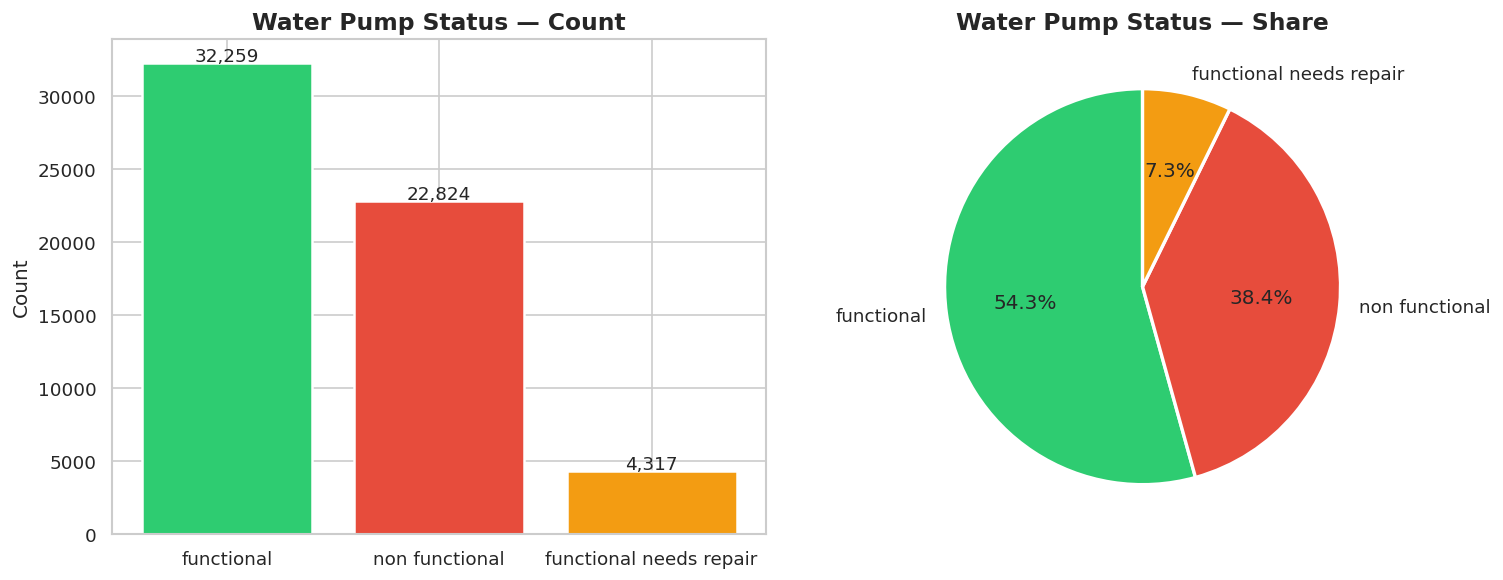

status_group
functional                 54.31
non functional             38.42
functional needs repair     7.27


In [6]:
target_counts = train['status_group'].value_counts()
target_pct    = train['status_group'].value_counts(normalize=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

palette = {'functional': '#2ecc71', 'functional needs repair': '#f39c12', 'non functional': '#e74c3c'}
colors  = [palette.get(c, '#888') for c in target_counts.index]

# Bar chart
axes[0].bar(target_counts.index, target_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Water Pump Status — Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 100, f'{v:,}', ha='center', fontsize=11)

# Pie chart
axes[1].pie(target_counts.values, labels=target_counts.index, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Water Pump Status — Share', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(target_pct.round(2).to_string())

Missing Values

In [7]:
missing = train.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(train) * 100).round(2)

print(pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct}))

# Zero values that often encode missing
zero_cols = ['longitude', 'latitude', 'gps_height', 'population', 'construction_year', 'amount_tsh']
zero_counts = {c: (train[c] == 0).sum() for c in zero_cols if c in train.columns}
print('\n=== Zero-value counts (often encode missing) ===')
print(pd.Series(zero_counts).sort_values(ascending=False))

                   Missing Count  Missing %
scheme_name                28810      48.50
scheme_management           3878       6.53
installer                   3655       6.15
funder                      3637       6.12
public_meeting              3334       5.61
permit                      3056       5.14
subvillage                   371       0.62
wpt_name                       2       0.00

=== Zero-value counts (often encode missing) ===
amount_tsh           41639
population           21381
construction_year    20709
gps_height           20438
longitude             1812
latitude                 0
dtype: int64


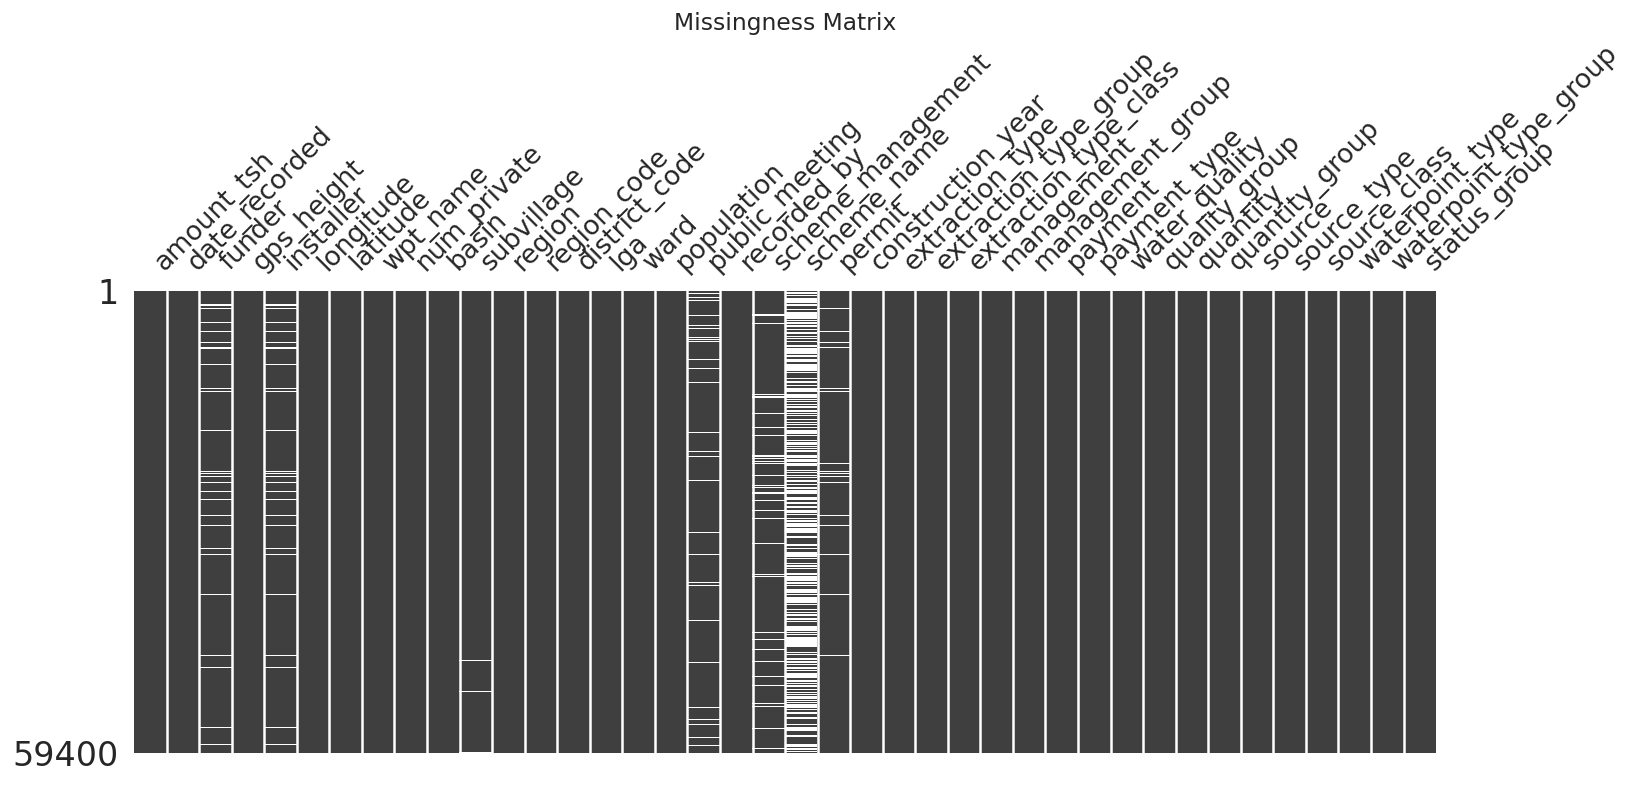

In [8]:
msno.matrix(train, figsize=(14, 5), sparkline=False)
plt.title('Missingness Matrix', fontsize=14)
plt.show()

Numerical Features

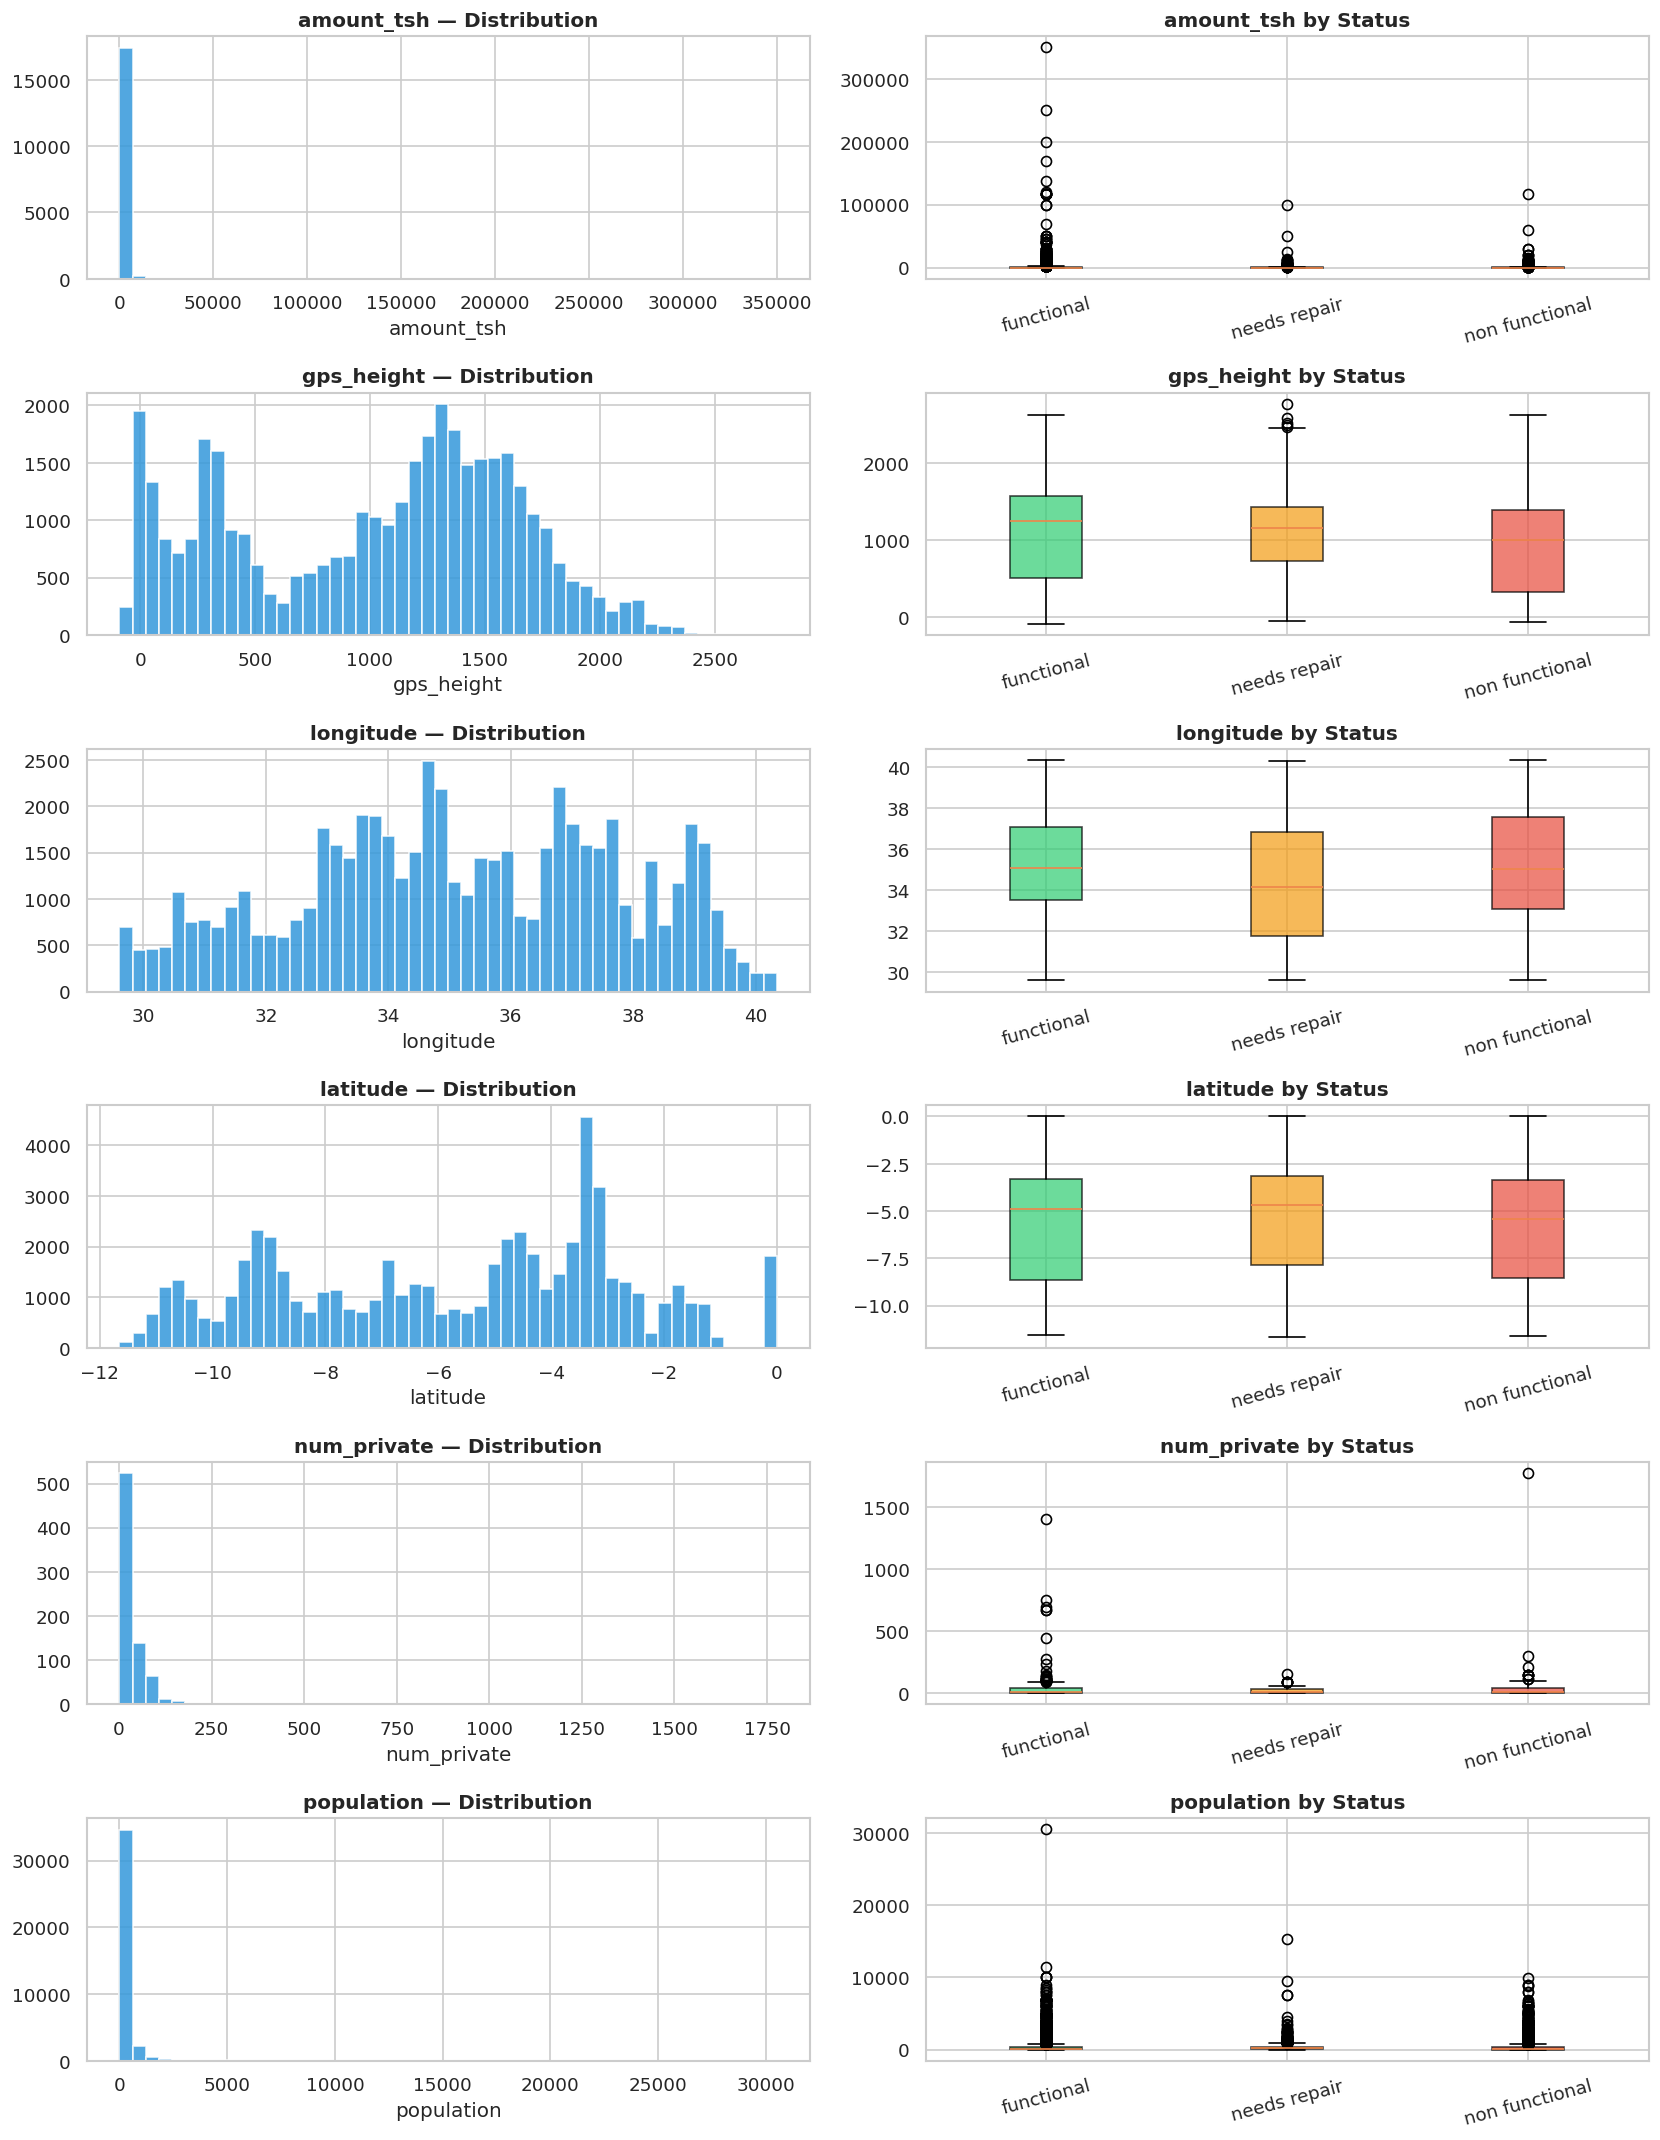

In [10]:
num_cols = ['amount_tsh', 'gps_height', 'longitude', 'latitude', 'num_private', 'population']
num_cols = [c for c in num_cols if c in train.columns]

fig, axes = plt.subplots(len(num_cols), 2, figsize=(14, len(num_cols) * 3))

for i, col in enumerate(num_cols):
    data = train[col].replace(0, np.nan).dropna()

    # Histogram
    axes[i, 0].hist(data, bins=50, color='#3498db', edgecolor='white', alpha=0.85)
    axes[i, 0].set_title(f'{col} — Distribution', fontweight='bold')
    axes[i, 0].set_xlabel(col)

    # Box by status
    groups = [train.loc[train['status_group'] == s, col].replace(0, np.nan).dropna()
              for s in ['functional', 'functional needs repair', 'non functional']]
    bp = axes[i, 1].boxplot(groups, patch_artist=True,
                             labels=['functional', 'needs repair', 'non functional'])
    for patch, color in zip(bp['boxes'], ['#2ecc71', '#f39c12', '#e74c3c']):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)
    axes[i, 1].set_title(f'{col} by Status', fontweight='bold')
    axes[i, 1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.show()

Categorical Feature

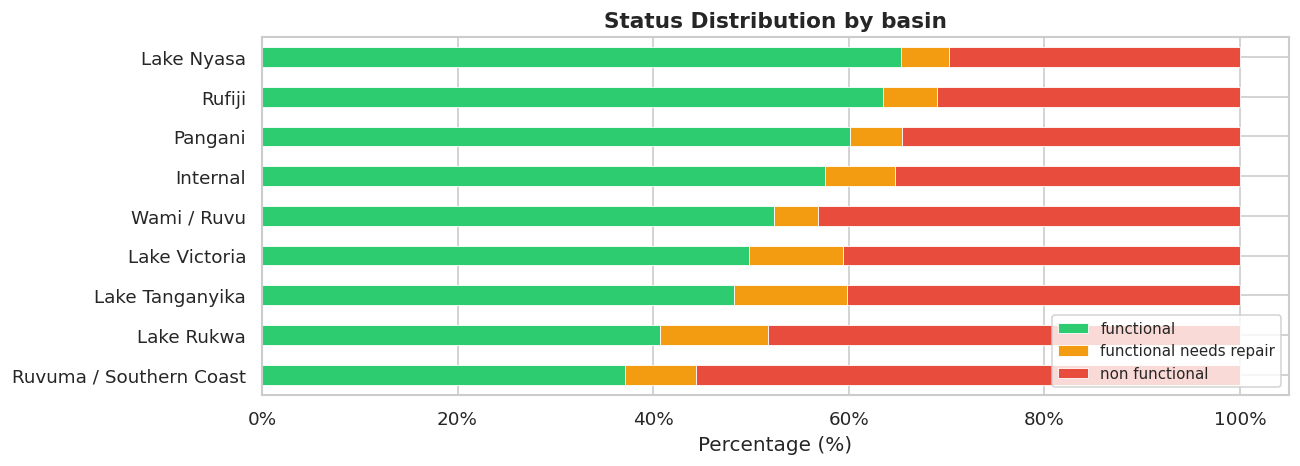

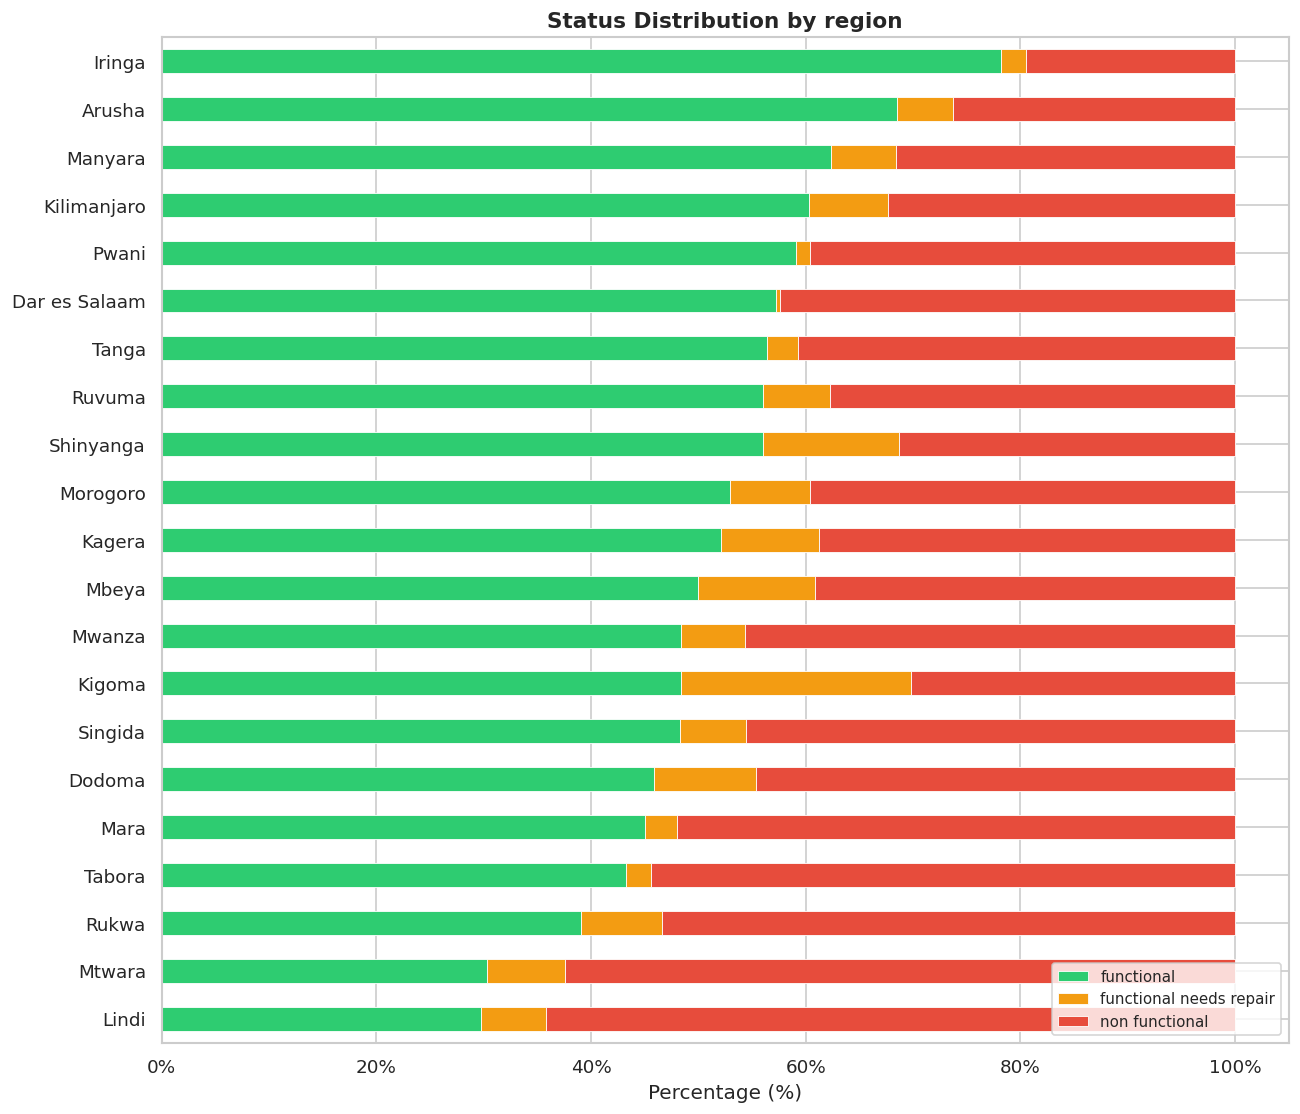

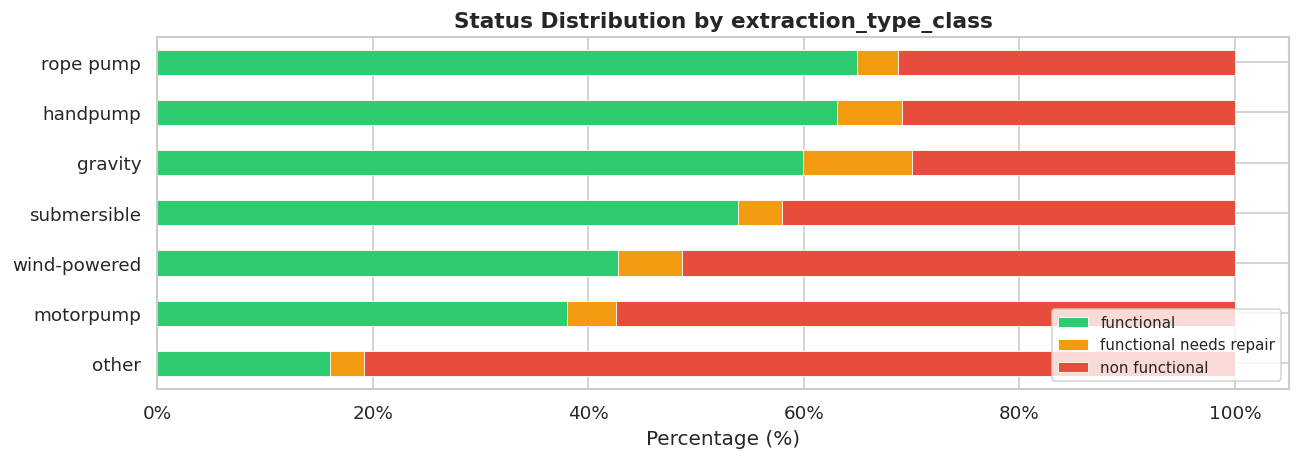

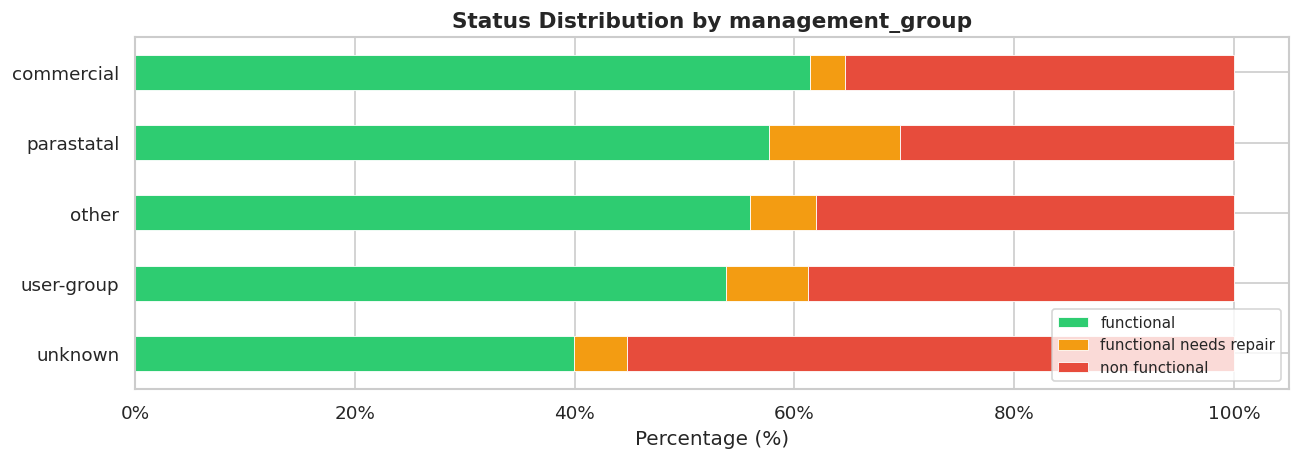

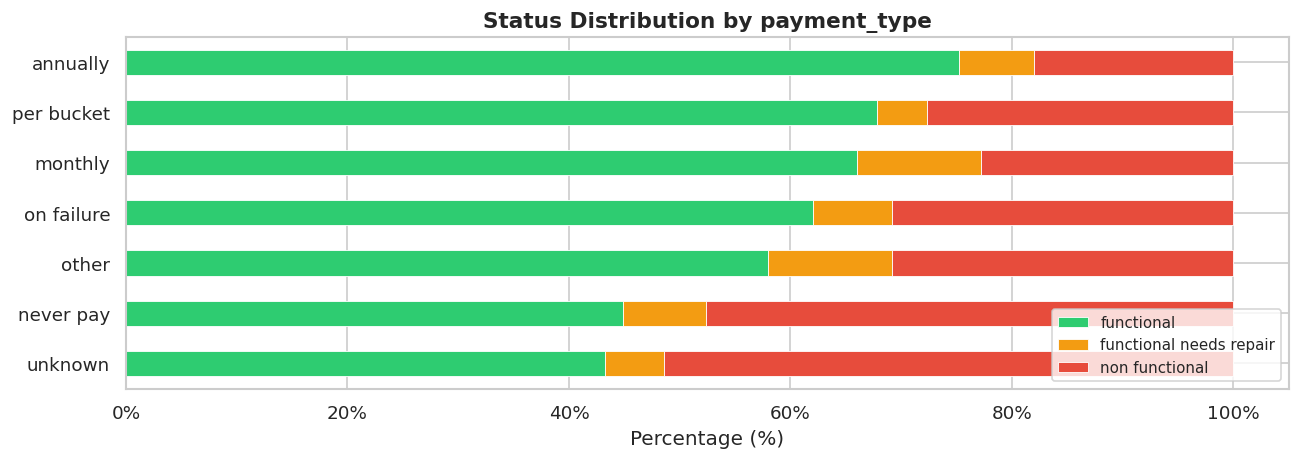

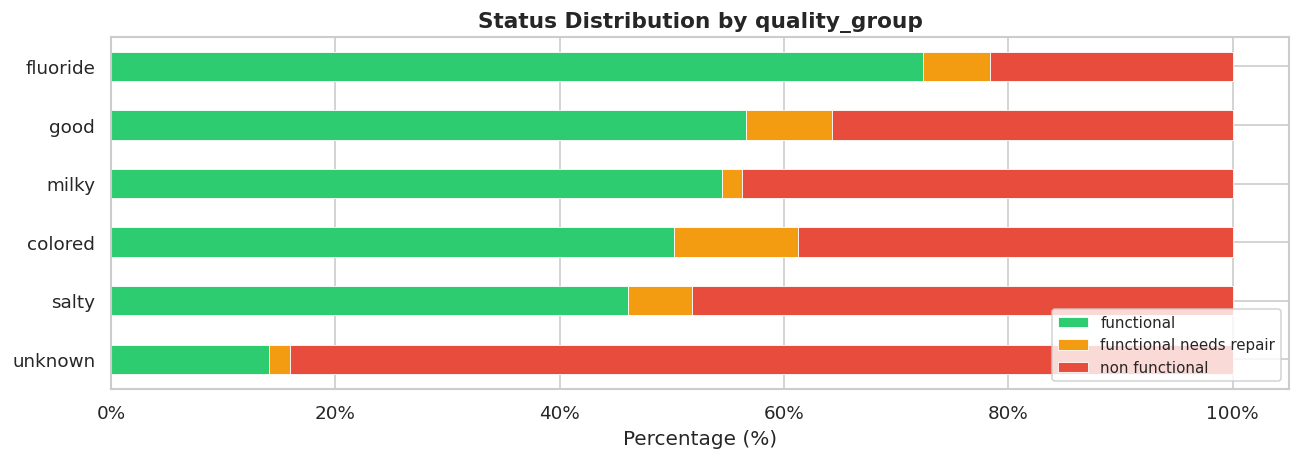

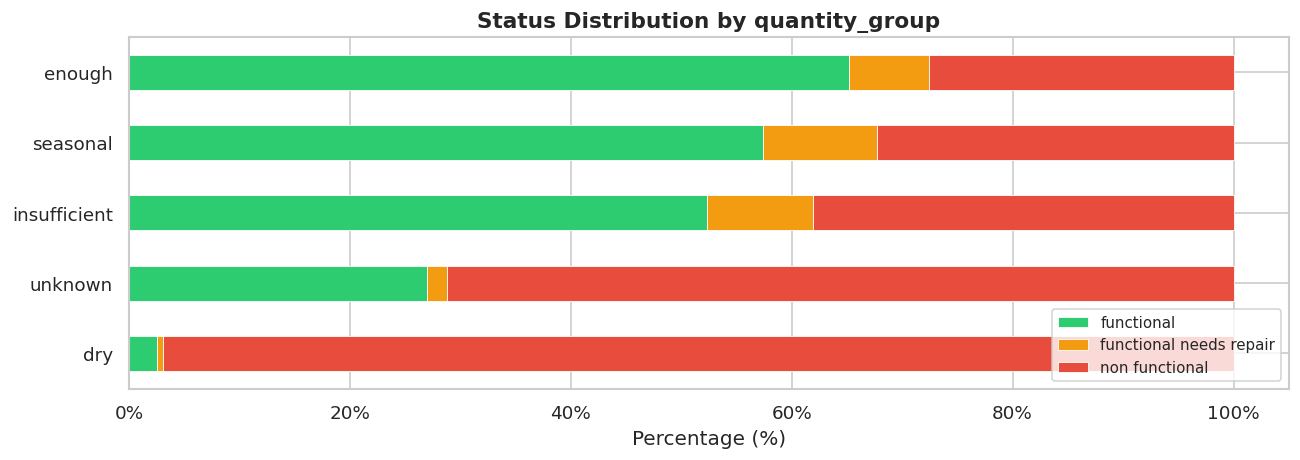

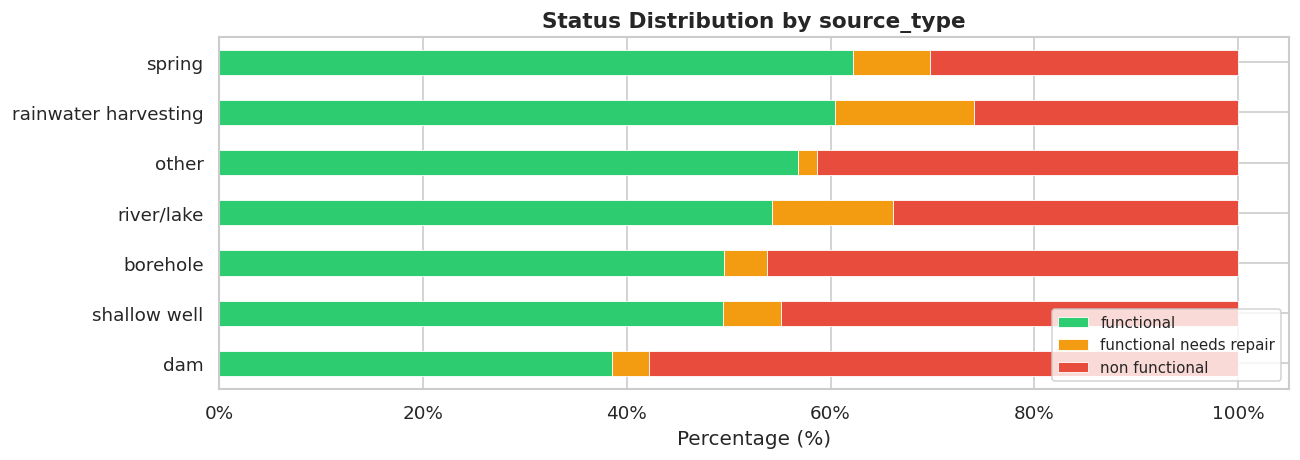

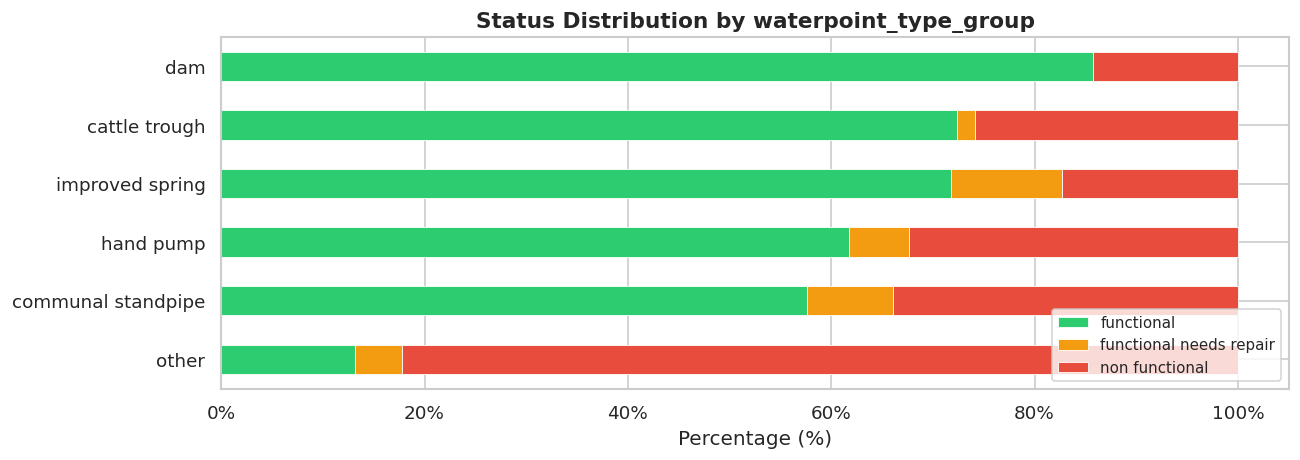

In [11]:
cat_cols = [
    'basin', 'region', 'extraction_type_class', 'management_group',
    'payment_type', 'quality_group', 'quantity_group',
    'source_type', 'waterpoint_type_group'
]
cat_cols = [c for c in cat_cols if c in train.columns]

palette_map = {'functional': '#2ecc71', 'functional needs repair': '#f39c12', 'non functional': '#e74c3c'}

for col in cat_cols:
    ct = pd.crosstab(train[col], train['status_group'], normalize='index') * 100
    ct = ct.sort_values('functional', ascending=True)

    ax = ct.plot(
        kind='barh', stacked=True, figsize=(11, max(4, len(ct) * 0.45)),
        color=[palette_map.get(c, '#aaa') for c in ct.columns],
        edgecolor='white', linewidth=0.5
    )
    ax.set_title(f'Status Distribution by {col}', fontsize=13, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.set_ylabel('')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.show()

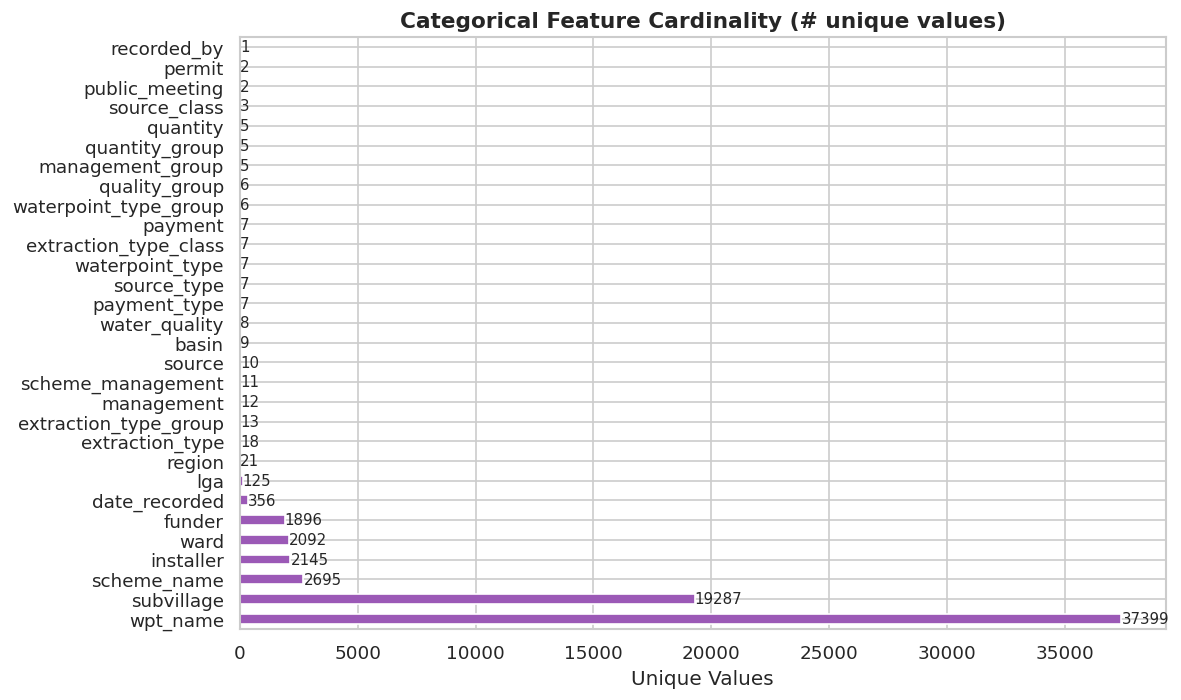

In [12]:
all_cat = train.select_dtypes('object').columns.drop('status_group')
cardinality = train[all_cat].nunique().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
cardinality.plot(kind='barh', ax=ax, color='#9b59b6', edgecolor='white')
ax.set_title('Categorical Feature Cardinality (# unique values)', fontsize=13, fontweight='bold')
ax.set_xlabel('Unique Values')
for i, v in enumerate(cardinality):
    ax.text(v + 1, i, str(v), va='center', fontsize=9)
plt.tight_layout()
plt.show()